# SCADA Functionality Test Visualiser

**Author:** Erick Chauke

SCADA stands for Supervisory Control and Data Acquisition, the system that runs a power plant and logs its measurements every second. Each grid-code functionality test leaves one of these logger spreadsheets, and today every one is checked by eye against the acceptance procedure. This notebook starts to automate that. Drop a test export into `data/`, run the notebook, and it parses the channels, compares the measured values against their setpoints and control modes, and plots whether the plant met each part of the procedure. The procedure is the SCADA Functionality Test Record (Rev 3) from NCSS, the National Control System Support group of the grid operator [1]. It is built to be general, so nothing is tied to one site. The single config cell below is all that changes between tests, and new sections are added one at a time. The first is the curtailment test.

## Setup

The config cell below is the only thing you edit. To run a new test, drop its spreadsheet into `data/` and run all cells. It locates the workbook, sets the site, time zone and highlighted event windows, and creates `outputs/`. Each figure is saved there with a short form of the site name as a prefix, so results from different plants never overwrite one another.

In [1]:
# Single config cell. To point this notebook at a different test, drop the new
# spreadsheet into the data/ folder and (only if more than one file is present)
# adjust INPUT_GLOB below. Nothing else in the notebook is edited to swap sites.

import re
from pathlib import Path

DATA_DIR = Path("data")          # input files live here (gitignored)
INPUT_GLOB = "*.xlsx"            # pattern that selects the logger workbook
OUTPUT_DIR = Path("outputs")     # every figure is saved here

SITE_NAME = "Hartebeesthoek"     # plant name shown in titles
TIME_ZONE_LABEL = "UTC"         # the logger timestamps are in this zone

# Optional scope restriction per test. Each section finds every occurrence of its test on
# its own, so leave an entry as None to scan the whole record (the normal case). Set a
# (start, end) pair only if you want to limit a test to one part of the day. The ceiling,
# ramp rates and exact times are always read from the data, never hard-coded.
EVENT_WINDOWS = {
    "curtailment": None,
    "power_gradient": None,
}

# Escape hatch for odd spreadsheets. The notebook normally finds each channel on its
# own, but if it ever guesses wrong, map the role to the exact column name here and it
# takes priority. Roles: poc_p, sp_p, ap_mode, pg_mode, ramp_up, ramp_down, timestamp,
# date, time. Example:
#   COLUMN_OVERRIDES = {"poc_p": "Active Power MW"}
COLUMN_OVERRIDES = {}

# Resolve the single input workbook without hard-coding its (confidential) name.
_candidates = sorted(DATA_DIR.glob(INPUT_GLOB))
assert len(_candidates) >= 1, f"no file matching {INPUT_GLOB} found in {DATA_DIR}"
INPUT_FILE = _candidates[0]

# Namespace saved figures by a safe slug of the site name, never the raw (and
# confidential) file name, so outputs from different sites never overwrite one
# another and no committed figure leaks the source file name.
SITE_SLUG = re.sub(r"[^0-9a-zA-Z]+", "_", SITE_NAME).strip("_").lower()

OUTPUT_DIR.mkdir(exist_ok=True)
_scope = {k: v for k, v in EVENT_WINDOWS.items() if v}
print(f"Site: {SITE_NAME} | timezone: {TIME_ZONE_LABEL}")
print(f"Input workbook resolved from {DATA_DIR}/ ({len(_candidates)} match)")
print(f"Figures will be saved to {OUTPUT_DIR}/ with prefix '{SITE_SLUG}_'")
print(f"Test scope overrides: {_scope or 'none, scanning the whole record'}")
print(f"Column overrides: {COLUMN_OVERRIDES or 'none'}")

Site: Hartebeesthoek | timezone: UTC
Input workbook resolved from data/ (1 match)
Figures will be saved to outputs/ with prefix 'hartebeesthoek_'
Test scope overrides: none, scanning the whole record
Column overrides: none


## Data ingestion and inspection

Before trusting any figure, this section loads the workbook and reports what is inside it: how many sheets there are, the row and column counts, and the type of each column. When a workbook has several sheets the largest one is taken as the logged time series. Sheet names are not printed, because they can carry identifiers that should stay confidential. The output here is a structural check rather than a plot, and it is the moment to confirm the data matches what the test was meant to capture.

In [2]:
import pandas as pd

# Load every sheet so the real structure is confirmed before any narrative is built on
# it. sheet_name=None keeps a multi-sheet workbook from being reduced to its first tab,
# and na_values catches the string sentinels Excel exports leave behind.
sheets = pd.read_excel(INPUT_FILE, sheet_name=None, na_values=["NULL", "None", "NaN", ""])

print(f"Sheets found: {len(sheets)}")
for i, frame in enumerate(sheets.values(), start=1):
    print(f"  sheet {i}: {frame.shape[0]} rows x {frame.shape[1]} columns")

# Work from the sheet with the most rows, which is the logged time series. Sheet names
# are deliberately not printed, as they can carry confidential identifiers.
raw = max(sheets.values(), key=len)
print(f"\nUsing the largest sheet: {raw.shape[0]} rows x {raw.shape[1]} columns")

print("\nColumns and dtypes:")
for col, dtype in raw.dtypes.items():
    print(f"  {col:<26} {dtype}")

Sheets found: 1
  sheet 1: 7147 rows x 23 columns

Using the largest sheet: 7147 rows x 23 columns

Columns and dtypes:
  Date                       datetime64[ns]
  Time UTC(NC2)              object
  POC: P (MW)                float64
  POC: Q (MVAr)              float64
  POC: Freq (Hz)             float64
  POC: PF                    float64
  POC: Average Voltage (KV)  float64
  SP: P (MW)                 int64
  SP: Q (MVAr)               int64
  SP:Voltage (kV)            int64
  SP: PF                     int64
  SP: P-Delta (%)            int64
  f used by f control (during test) float64
  SP:Ramp up (MW/min)        int64
  SP:Ramp down (MW/min)      int64
  Mode:Q                     int64
  Mode:V                     int64
  Mode:PF                    int64
  Mode: Active Power         int64
  Mode: p-Delta              int64
  Mode: Power Gradient       int64
  SP:Droop V (%)             int64
  SP:Droop F (%)             int64


## Data cleaning, parsing and channel resolution

Different sites do not label their columns identically, so the notebook does not assume fixed names. Each value it needs is described by a role, such as the measured active power, the active-power setpoint, the curtailment-mode flag, and the date and time. A small resolver then matches that role to whatever column carries it, ignoring case, spacing and punctuation. If a match is ever wrong, the real name can be forced through `COLUMN_OVERRIDES` in the config cell.

With the columns resolved, the cleaning runs. The time of day is read whether it arrives as a quoted string, a plain time, a full datetime or an Excel fraction of a day, then joined to the date to form the timestamp index. Columns that hold only zero and one become off and on flags, and every other channel is forced to a number so stray text turns into a missing value. The printout reports what was resolved and the time span, without showing any raw rows.

In [3]:
# --- Channel resolution -------------------------------------------------------
# Sites label columns differently, so each logical channel (its role) is matched to
# whatever column carries it, ignoring case, spacing and punctuation. If a guess is
# ever wrong, set the real name in COLUMN_OVERRIDES in the config cell and it wins.

def _norm(name):
    # Lower-case, then turn any run of non-alphanumeric characters into one space.
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9]+", " ", str(name).lower())).strip()

CHANNEL_PATTERNS = {
    "timestamp": [r"date.*time", r"\btimestamp\b", r"\bdatetime\b"],
    "date":      [r"\bdate\b"],
    "time":      [r"\btime\b"],
    "poc_p":     [r"poc.*\bp\b.*mw", r"poc.*active power", r"active power.*poc",
                  r"measured.*\bp\b.*mw"],
    "sp_p":      [r"\bsp\b.*\bp\b.*mw", r"set ?point.*\bp\b.*mw", r"\bp\b.*set ?point"],
    "ap_mode":   [r"mode.*active power", r"active power.*mode", r"curtail.*mode",
                  r"mode.*curtail"],
    "pg_mode":   [r"mode.*power gradient", r"power gradient.*mode", r"mode.*gradient",
                  r"gradient.*mode"],
    "ramp_up":   [r"ramp up", r"up ramp", r"ramp.*up.*min"],
    "ramp_down": [r"ramp down", r"down ramp", r"ramp.*down.*min"],
}

_norms = {col: _norm(col) for col in raw.columns}

def resolve(role, required=False):
    override = COLUMN_OVERRIDES.get(role)
    if override is not None:
        if override not in raw.columns:
            raise KeyError(f"COLUMN_OVERRIDES['{role}'] = '{override}' is not a column")
        return override
    for pattern in CHANNEL_PATTERNS.get(role, []):
        for col, norm in _norms.items():
            if re.search(pattern, norm):
                return col
    if required:
        raise KeyError(
            f"could not find a column for the '{role}' channel. Set "
            f"COLUMN_OVERRIDES['{role}'] in the config cell to one of: {list(raw.columns)}"
        )
    return None

def _parse_time_of_day(series):
    # Time of day may be a quoted string ('08:00:47'), a plain time string, a datetime,
    # or an Excel fraction of a day. Try each in turn.
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_timedelta(series, unit="D")
    s = series.astype(str).str.strip().str.strip("'\"")
    td = pd.to_timedelta(s, errors="coerce")
    if td.notna().any():
        return td
    dt = pd.to_datetime(s, errors="coerce")
    return dt - dt.dt.normalize()

# --- Build the working frame and its timestamp index --------------------------
df = raw.copy()

ts_col = resolve("timestamp")
if ts_col is not None:
    index = pd.to_datetime(df[ts_col], errors="coerce")
    source = f"combined column '{ts_col}'"
    df = df.drop(columns=[ts_col])
else:
    date_col = resolve("date", required=True)
    time_col = resolve("time")
    if pd.api.types.is_numeric_dtype(df[date_col]):
        # Plain numbers in a date column are Excel serial days.
        date_part = pd.to_datetime(df[date_col], unit="D", origin="1899-12-30", errors="coerce")
    else:
        date_part = pd.to_datetime(df[date_col], errors="coerce")
    date_part = date_part.dt.normalize()
    if time_col is not None and time_col != date_col:
        index = date_part + _parse_time_of_day(df[time_col])
        source = f"'{date_col}' plus '{time_col}'"
        df = df.drop(columns=[c for c in {date_col, time_col} if c in df.columns])
    else:
        index = date_part
        source = f"'{date_col}' alone (no separate time column found)"
        df = df.drop(columns=[date_col])

if index.isna().all():
    raise ValueError("could not parse any timestamps; check the date and time columns "
                     "or set COLUMN_OVERRIDES in the config cell")
df.index = pd.DatetimeIndex(index, name="timestamp")
df = df[~df.index.isna()].sort_index()

# --- Column types -------------------------------------------------------------
# A column is an on/off flag only if its name looks like one (mode, flag, status,
# enable) and its values are binary. The name test stops a setpoint that happens to be
# constant or binary in one capture from being mistaken for a flag.
def _is_flag(name, col):
    looks_like_flag = any(k in _norm(name) for k in ["mode", "flag", "status", "enable"])
    vals = set(pd.unique(col.dropna()))
    binary = 0 < len(vals) <= 2 and vals <= {0, 1, True, False, 0.0, 1.0, "0", "1"}
    return looks_like_flag and binary

mode_cols = [c for c in df.columns if _is_flag(c, df[c])]
df[mode_cols] = df[mode_cols].astype(float).astype(bool)

measure_cols = [c for c in df.columns if c not in mode_cols]
df[measure_cols] = df[measure_cols].apply(pd.to_numeric, errors="coerce")

# --- Shared event helpers (reused by every test section) ----------------------
# These let each test section find every occurrence of an event for itself, rather than
# relying on a single hand-set window, so a spreadsheet with the same test repeated still
# yields one graph per occurrence.
def on_segments(flag):
    # Contiguous runs where a boolean flag is on, returned as (start, end) timestamp
    # pairs. start is the first on sample; end is the sample where it goes off again.
    flag = flag.astype(bool)
    spans, start = [], None
    for ts, v in flag.items():
        if v and start is None:
            start = ts
        elif not v and start is not None:
            spans.append((start, ts)); start = None
    if start is not None:
        spans.append((start, flag.index[-1]))
    return spans

def window_around(start, end, before="90s", after="90s"):
    # A slice of df padded around an episode and clipped to the data bounds, so the
    # setpoint-sent lead-in and the recovery tail are both captured.
    lo = max(df.index[0], start - pd.Timedelta(before))
    hi = min(df.index[-1], end + pd.Timedelta(after))
    return df.loc[lo:hi]

# --- Report (no raw rows or identifiers are printed) --------------------------
step = df.index.to_series().diff().median()
print(f"Timestamp index built from {source}")
print(f"Parsed {len(df)} rows spanning {df.index.min()} to {df.index.max()} {TIME_ZONE_LABEL}")
print(f"Median sample step: {step}")
print("Resolved channels:")
for role in ["poc_p", "sp_p", "ap_mode", "pg_mode", "ramp_up", "ramp_down"]:
    print(f"  {role:10} -> {resolve(role)}")
print(f"On/off flag columns: {mode_cols}")
print(f"Missing values after numeric coercion: {int(df[measure_cols].isna().sum().sum())}")

Timestamp index built from 'Date' plus 'Time UTC(NC2)'
Parsed 7147 rows spanning 2026-05-27 08:00:47 to 2026-05-27 09:59:53 UTC
Median sample step: 0 days 00:00:01
Resolved channels:
  poc_p      -> POC: P (MW)
  sp_p       -> SP: P (MW)
  ap_mode    -> Mode: Active Power
  pg_mode    -> Mode: Power Gradient
  ramp_up    -> SP:Ramp up (MW/min)
  ramp_down  -> SP:Ramp down (MW/min)
On/off flag columns: ['Mode:Q', 'Mode:V', 'Mode:PF', 'Mode: Active Power', 'Mode: p-Delta', 'Mode: Power Gradient']
Missing values after numeric coercion: 0


## Curtailment, the absolute production constraint test

Curtailment is the grid operator capping how much power the plant may export. The plant is given a ceiling in megawatts (MW); when curtailment mode is switched on it must pull its output down to sit at or below that ceiling, then return to normal when the mode is switched off. This is the absolute production constraint test in the acceptance procedure [1], checked in three steps: the ceiling setpoint is sent while the mode is still off and the output should only acknowledge it, then the mode is switched on and the output should fall to the ceiling and hold, then the mode is switched off and the output should recover.

The cell below finds every standalone curtailment window in the record, meaning curtailment mode on while the power gradient limiter is off, and draws one graph per window. For each it reads the ceiling from the data, marks the setpoint-sent, mode-on and mode-off moments with their times, and prints findings for the three checks.

Standalone curtailment windows found: 2

Curtailment window 1 of 2  ceiling 35 MW  figure hartebeesthoek_curtailment_081531.png
  1. The setpoint to 35 MW was sent at 08:15:11 while the mode was still off and the output kept running, so the command was received but inert.
  2. After mode ON at 08:15:31 the output settled near 35 MW, at or below the 35 MW ceiling, so the plant was curtailed to the ceiling.
  3. After mode OFF at 08:16:11 the output recovered to about 48 MW, back near its earlier 50 MW, so the plant returned to full output.


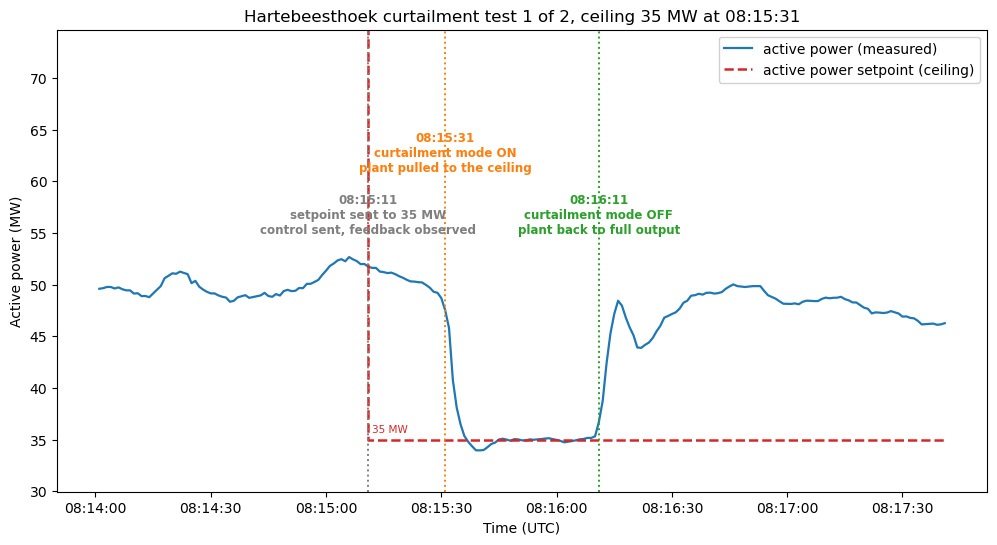


Curtailment window 2 of 2  ceiling 25 MW  figure hartebeesthoek_curtailment_084859.png
  1. The setpoint to 25 MW was sent at 08:48:43 while the mode was still off and the output kept running, so the command was received but inert.
  2. After mode ON at 08:48:59 the output settled near 25 MW, at or below the 25 MW ceiling, so the plant was curtailed to the ceiling.
  3. After mode OFF at 08:49:45 the output recovered to about 45 MW, back near its earlier 49 MW, so the plant returned to full output.


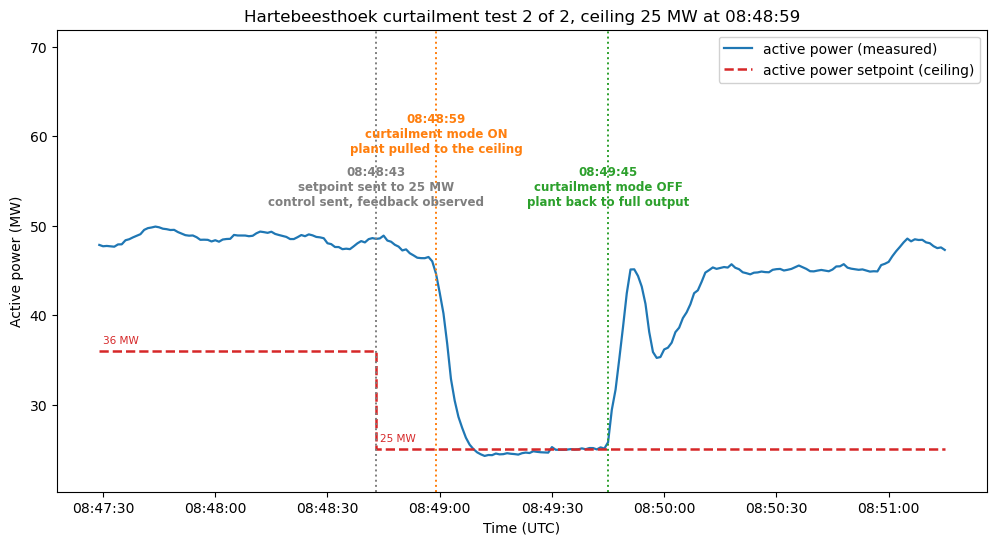

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

poc_col = resolve("poc_p", required=True)
sp_col = resolve("sp_p", required=True)
ap_col = resolve("ap_mode", required=True)
pg_col = resolve("pg_mode")  # optional, used to exclude power-gradient-driven windows

# Scope: a configured window restricts the search; otherwise scan the whole record.
cfg = EVENT_WINDOWS.get("curtailment")
scope = df.loc[cfg[0]:cfg[1]] if (cfg and all(cfg)) else df

# A standalone curtailment is curtailment mode on while power gradient is off. The
# windows where power gradient is also on belong to the power gradient test, not here.
windows = []
for s, e in on_segments(scope[ap_col]):
    pg_frac = scope[pg_col].astype(bool).loc[s:e].mean() if pg_col else 0.0
    if pg_frac < 0.5:
        windows.append((s, e))

def plot_curtailment(seg_start, seg_end, n, total):
    win = window_around(seg_start, seg_end)
    ap = win[ap_col].astype(bool)
    poc_p = win[poc_col]
    sp_p = win[sp_col]

    mode_on = seg_start
    after_on = ap.loc[mode_on:]
    off_idx = after_on.index[~after_on]
    mode_off = off_idx[0] if len(off_idx) else None

    # The ceiling setpoint: the last genuine step at or before mode ON. If none, the
    # setpoint was already at its ceiling before this window.
    sp_mask = sp_p.ne(sp_p.shift())
    if len(sp_mask):
        sp_mask.iloc[0] = False
    steps_before = sp_p.index[sp_mask & (sp_p.index <= mode_on)]
    sp_sent = steps_before[-1] if len(steps_before) else None
    ceiling = sp_p.loc[mode_on]
    combined = sp_sent is not None and abs(mode_on - sp_sent) <= pd.Timedelta(seconds=5)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(poc_p.index, poc_p, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax.plot(sp_p.index, sp_p, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
            label="active power setpoint (ceiling)")

    # Label each setpoint level on the red line, matching the power gradient plot. Levels
    # that sit outside the plotted range, such as the pre-curtailment setpoint far above
    # the operating output, are skipped so they do not produce clipped labels.
    for ts, val in sp_p[sp_p.ne(sp_p.shift())].items():
        if val < poc_p.min() - 5 or val > poc_p.max() + 5:
            continue
        ax.annotate(f"{val:.0f} MW", xy=(ts, val), xytext=(3, 4), textcoords="offset points",
                    ha="left", va="bottom", fontsize=7.5, color="#d62728",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

    events = []
    if combined:
        events.append((mode_on, "#ff7f0e",
                       f"{mode_on:%H:%M:%S}\nsetpoint sent to {ceiling:.0f} MW and mode ON together\nplant pulled to the ceiling"))
    else:
        if sp_sent is not None:
            events.append((sp_sent, "#7f7f7f",
                           f"{sp_sent:%H:%M:%S}\nsetpoint sent to {ceiling:.0f} MW\ncontrol sent, feedback observed"))
        events.append((mode_on, "#ff7f0e",
                       f"{mode_on:%H:%M:%S}\ncurtailment mode ON\nplant pulled to the ceiling"))
    if mode_off is not None:
        events.append((mode_off, "#2ca02c",
                       f"{mode_off:%H:%M:%S}\ncurtailment mode OFF\nplant back to full output"))

    ymax, ymin = poc_p.max(), poc_p.min()
    for i, (ts, colour, text) in enumerate(events):
        ax.axvline(ts, color=colour, ls=":", lw=1.4)
        ax.annotate(text, xy=(ts, ymax), xytext=(ts, ymax + 2 + (i % 2) * 6),
                    ha="center", va="bottom", fontsize=8.5, color=colour, fontweight="bold")

    ax.set_ylim(ymin - 4, ymax + 22)
    ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax.set_ylabel("Active power (MW)")
    ax.set_title(f"{SITE_NAME} curtailment test {n} of {total}, ceiling {ceiling:.0f} MW at {mode_on:%H:%M:%S}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.legend(loc="upper right", framealpha=0.9)

    out_path = OUTPUT_DIR / f"{SITE_SLUG}_curtailment_{mode_on:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    # Findings for this window, stated against what the data actually shows, so a window
    # where the plant did not curtail or did not recover reads that way, not as a pass.
    story = []
    if combined:
        story.append(f"The setpoint to {ceiling:.0f} MW and curtailment mode were switched on together "
                     f"at {mode_on:%H:%M:%S}, so there is no separate sent-but-inert phase here.")
    elif sp_sent is not None:
        story.append(f"The setpoint to {ceiling:.0f} MW was sent at {sp_sent:%H:%M:%S} while the mode was "
                     f"still off and the output kept running, so the command was received but inert.")
    else:
        story.append("The setpoint was already at its ceiling before this window, so the moment it was "
                     "first sent is not captured here.")

    held = float(poc_p[ap].median())
    ceil_tol = max(1.0, 0.05 * abs(ceiling))
    if held <= ceiling + ceil_tol:
        story.append(f"After mode ON at {mode_on:%H:%M:%S} the output settled near {held:.0f} MW, at or "
                     f"below the {ceiling:.0f} MW ceiling, so the plant was curtailed to the ceiling.")
    else:
        story.append(f"After mode ON at {mode_on:%H:%M:%S} the output stayed near {held:.0f} MW, above the "
                     f"{ceiling:.0f} MW ceiling, so it was not curtailed to the ceiling in this window.")

    pre = poc_p[poc_p.index < mode_on]
    pre_level = float(pre.median()) if len(pre) else None
    if mode_off is not None:
        after = poc_p[poc_p.index > mode_off]
        if len(after):
            after_level = float(after.median())
            if pre_level is None:
                story.append(f"After mode OFF at {mode_off:%H:%M:%S} the output moved to about {after_level:.0f} MW.")
            elif after_level >= pre_level - max(2.0, 0.1 * abs(pre_level)):
                story.append(f"After mode OFF at {mode_off:%H:%M:%S} the output recovered to about {after_level:.0f} MW, "
                             f"back near its earlier {pre_level:.0f} MW, so the plant returned to full output.")
            else:
                story.append(f"After mode OFF at {mode_off:%H:%M:%S} the output recovered only to about {after_level:.0f} MW, "
                             f"below its earlier {pre_level:.0f} MW, so it did not fully return in this window.")
        else:
            story.append(f"Mode OFF at {mode_off:%H:%M:%S} sits at the window edge, so recovery is not captured here.")
    else:
        story.append("Curtailment mode is still on at the end of this window, so the return to full output "
                     "is not captured here.")

    print(f"\nCurtailment window {n} of {total}  ceiling {ceiling:.0f} MW  figure {out_path.name}")
    for k, line in enumerate(story, start=1):
        print(f"  {k}. {line}")
    plt.show()

print(f"Standalone curtailment windows found: {len(windows)}")
if not windows:
    print("Curtailment mode is never on without power gradient in this scope, so there is "
          "nothing to plot here.")
for n, (seg_start, seg_end) in enumerate(windows, start=1):
    plot_curtailment(seg_start, seg_end, n, len(windows))

### What the curtailment plots show

Each standalone curtailment window tells the same three-step story, and the notebook draws one plot per window so they can be compared at a glance. Before the constraint bites, the plant runs at its operating level and the ceiling setpoint is sent while the mode is still off: the output does not move, which is the first check, the command received but inert [1]. When the mode is switched on the output falls within seconds to sit on the ceiling and holds there, respecting it as a hard maximum rather than a target to climb to. When the mode is switched off the output climbs back toward its earlier level. The printed findings under each plot carry that window's exact times, its ceiling and the recovered level, and say plainly if any phase was not captured in the data.

## Power gradient constraint test

The power gradient constraint limits how fast the plant may change its output. Instead of jumping straight to a new setpoint, the plant must move towards it at a commanded rate, measured in megawatts per minute (MW/min), with a separate limit for ramping up and ramping down. The procedure [1] sets a down rate, switches power gradient mode on, commands a lower setpoint and checks the plant descends at that rate, then sets an up rate, commands a higher setpoint and checks the plant climbs at that rate.

The cell below finds every power gradient window in the record and draws one graph per window. While the mode is engaged it measures the slope the plant follows for each setpoint change by least-squares and compares it against the commanded limit for that direction. The measured ramp is drawn as a guide line, the curtailment mode that actually drives each move is marked with its on and off times along the bottom, and the findings give the observed rate beside the commanded one, anchored to the interval it was measured over.

Power gradient windows found: 2

Power gradient window 1 of 2  figure hartebeesthoek_power_gradient_081911.png
  1. Power gradient mode was switched on at 08:19:11, so the plant should move between setpoints at the commanded rate rather than as fast as it can.
  2. At 08:19:35 the setpoint moved down to 26 MW, and from 08:20:03 to 08:20:51 the plant ramped at about 20 MW/min, close to the limit of 20 MW/min.
  3. At 08:22:06 the setpoint moved up to 36 MW, and from 08:22:11 to 08:22:51 the plant ramped at about 10 MW/min, close to the limit of 10 MW/min.
  4. Power gradient mode was released at 08:23:27.


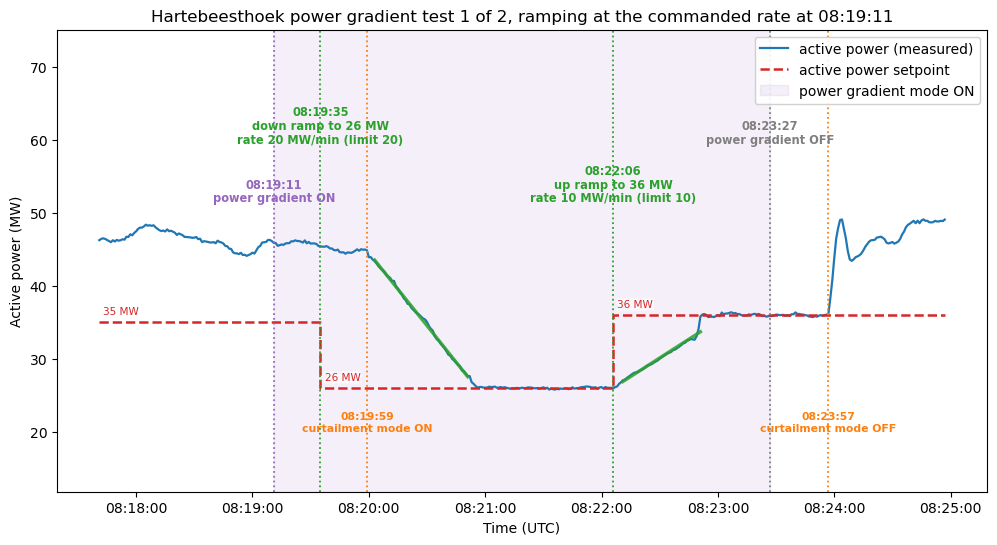


Power gradient window 2 of 2  figure hartebeesthoek_power_gradient_085141.png
  1. Power gradient mode was switched on at 08:51:41, so the plant should move between setpoints at the commanded rate rather than as fast as it can.
  2. At 08:52:15 the setpoint moved down to 39 MW, and from 08:52:29 to 08:53:21 the plant ramped at about 11 MW/min, close to the limit of 10 MW/min.
  3. At 08:54:47 the setpoint moved up to 44 MW, and from 08:54:52 to 08:55:39 the plant ramped at about 6 MW/min, close to the limit of 5 MW/min.
  4. Power gradient mode was released at 08:57:24.


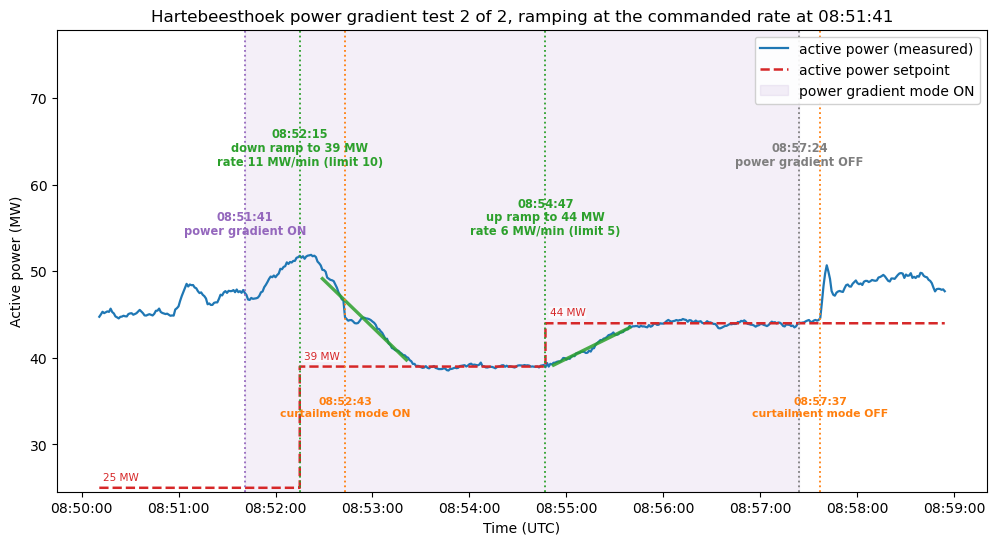

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pg_col = resolve("pg_mode", required=True)
poc_col = resolve("poc_p", required=True)
sp_col = resolve("sp_p", required=True)
ap_col = resolve("ap_mode")
up_col = resolve("ramp_up")
down_col = resolve("ramp_down")

# Scope: a configured window restricts the search; otherwise scan the whole record.
cfg = EVENT_WINDOWS.get("power_gradient")
scope = df.loc[cfg[0]:cfg[1]] if (cfg and all(cfg)) else df
windows = on_segments(scope[pg_col])

def measure_ramp(seg, p0, target):
    # Robust ramp rate by a least-squares fit over the 10 percent to 90 percent rise, so
    # the slope is not thrown off by dead time before the move or by a small move ending
    # early. Returns (rate_mw_per_min, t_start, p_start, t_end, p_end), or None if the
    # move is too small to measure.
    span = target - p0
    if abs(span) < 0.5:
        return None
    lo, hi = p0 + 0.1 * span, p0 + 0.9 * span
    if span > 0:
        s_idx, e_idx = seg.index[seg >= lo], seg.index[seg >= hi]
    else:
        s_idx, e_idx = seg.index[seg <= lo], seg.index[seg <= hi]
    t_start = s_idx[0] if len(s_idx) else seg.index[0]
    e_after = e_idx[e_idx > t_start]
    t_end = e_after[0] if len(e_after) else seg.index[-1]
    fit = seg.loc[t_start:t_end]
    if len(fit) < 2:
        return None
    x_min = (fit.index - fit.index[0]).total_seconds().to_numpy() / 60.0
    coef = np.polyfit(x_min, fit.to_numpy(), 1)
    return (float(coef[0]), t_start, float(np.polyval(coef, x_min[0])),
            t_end, float(np.polyval(coef, x_min[-1])))

def plot_power_gradient(seg_start, seg_end, n, total):
    win = window_around(seg_start, seg_end)
    pg = win[pg_col].astype(bool)
    poc = win[poc_col]
    sp = win[sp_col]

    pg_on = seg_start
    after_on = pg.loc[pg_on:]
    off_idx = after_on.index[~after_on]
    pg_off = off_idx[0] if len(off_idx) else None
    span_hi = pg_off if pg_off is not None else win.index[-1]

    # Setpoint steps while power gradient is engaged: each one starts a ramp.
    sp_mask = sp.ne(sp.shift())
    if len(sp_mask):
        sp_mask.iloc[0] = False
    steps = sp.index[sp_mask]
    steps = steps[(steps >= pg_on) & (steps <= span_hi)]

    ramps = []
    for k, ts in enumerate(steps):
        target = sp.loc[ts]
        p0 = poc.loc[ts]
        nxt = steps[k + 1] if k + 1 < len(steps) else span_hi
        m = measure_ramp(poc.loc[ts:nxt], p0, target)
        if m is None:
            continue
        observed, t_start, p_start, t_end, p_end = m
        direction = "down" if target < p0 else "up"
        rate_col = down_col if direction == "down" else up_col
        commanded = win[rate_col].loc[ts] if rate_col else None
        ramps.append(dict(ts=ts, target=target, direction=direction, t_start=t_start, t_end=t_end,
                          p_start=p_start, p_end=p_end, observed=observed, commanded=commanded))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(poc.index, poc, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax.plot(sp.index, sp, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
            label="active power setpoint")
    span_end = pg_off if pg_off is not None else win.index[-1]
    ax.axvspan(pg_on, span_end, color="#9467bd", alpha=0.10, label="power gradient mode ON")

    for r in ramps:
        ax.plot([r["t_start"], r["t_end"]], [r["p_start"], r["p_end"]], color="#2ca02c", lw=2.4, alpha=0.85)

    for ts, val in sp[sp.ne(sp.shift())].items():
        ax.annotate(f"{val:.0f} MW", xy=(ts, val), xytext=(3, 4), textcoords="offset points",
                    ha="left", va="bottom", fontsize=7.5, color="#d62728",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

    ymax, ymin = poc.max(), poc.min()

    # Top markers: power gradient on/off and each ramp. "rate X MW/min (limit Y)" gives the
    # slope the plant followed against the commanded limit.
    top_events = [(pg_on, "#9467bd", f"{pg_on:%H:%M:%S}\npower gradient ON")]
    for r in ramps:
        cmd = f"{r['commanded']:.0f}" if r["commanded"] is not None else "n/a"
        top_events.append((r["ts"], "#2ca02c",
                           f"{r['ts']:%H:%M:%S}\n{r['direction']} ramp to {r['target']:.0f} MW\n"
                           f"rate {abs(r['observed']):.0f} MW/min (limit {cmd})"))
    if pg_off is not None:
        top_events.append((pg_off, "#7f7f7f", f"{pg_off:%H:%M:%S}\npower gradient OFF"))
    for i, (ts, colour, text) in enumerate(top_events):
        ax.axvline(ts, color=colour, ls=":", lw=1.3)
        ax.annotate(text, xy=(ts, ymax), xytext=(ts, ymax + 2 + (i % 2) * 8),
                    ha="center", va="bottom", fontsize=8.2, color=colour, fontweight="bold")

    # Bottom markers: curtailment mode on and off, with their times.
    ap_spans = on_segments(win[ap_col]) if ap_col else []
    for s, e in ap_spans:
        for ts, text in ((s, "curtailment mode ON"), (e, "curtailment mode OFF")):
            ax.axvline(ts, color="#ff7f0e", ls=":", lw=1.3)
            ax.annotate(f"{ts:%H:%M:%S}\n{text}", xy=(ts, ymin), xytext=(ts, ymin - 3),
                        ha="center", va="top", fontsize=7.8, color="#ff7f0e", fontweight="bold")

    ax.set_ylim(ymin - 14, ymax + 26)
    ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax.set_ylabel("Active power (MW)")
    ax.set_title(f"{SITE_NAME} power gradient test {n} of {total}, ramping at the commanded rate at {pg_on:%H:%M:%S}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.legend(loc="upper right", framealpha=0.9)

    out_path = OUTPUT_DIR / f"{SITE_SLUG}_power_gradient_{pg_on:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    # Findings for this window, each ramp anchored to its measured interval.
    story = [f"Power gradient mode was switched on at {pg_on:%H:%M:%S}, so the plant should move "
             "between setpoints at the commanded rate rather than as fast as it can."]
    if ramps:
        for r in ramps:
            rate = f"{abs(r['observed']):.0f} MW/min"
            span = f"from {r['t_start']:%H:%M:%S} to {r['t_end']:%H:%M:%S}"
            if r["commanded"] is not None:
                diff = abs(r["observed"]) - r["commanded"]
                verdict = ("close to the limit" if abs(diff) <= 0.2 * r["commanded"]
                           else "faster than the limit" if diff > 0 else "slower than the limit")
                story.append(f"At {r['ts']:%H:%M:%S} the setpoint moved {r['direction']} to {r['target']:.0f} MW, "
                             f"and {span} the plant ramped at about {rate}, {verdict} of {r['commanded']:.0f} MW/min.")
            else:
                story.append(f"At {r['ts']:%H:%M:%S} the setpoint moved {r['direction']} to {r['target']:.0f} MW, "
                             f"and {span} the plant ramped at about {rate}; no rate limit was recorded for this move.")
    else:
        story.append("No setpoint change happens while power gradient is on, so the rate limit is not "
                     "exercised in this window.")
    if pg_off is not None:
        story.append(f"Power gradient mode was released at {pg_off:%H:%M:%S}.")
    else:
        story.append("Power gradient mode is still on at the end of this window.")

    print(f"\nPower gradient window {n} of {total}  figure {out_path.name}")
    for k, line in enumerate(story, start=1):
        print(f"  {k}. {line}")
    plt.show()

print(f"Power gradient windows found: {len(windows)}")
if not windows:
    print("Power gradient mode is never on in this scope, so there is nothing to plot here.")
for n, (seg_start, seg_end) in enumerate(windows, start=1):
    plot_power_gradient(seg_start, seg_end, n, len(windows))